# Figure 4f,g — Summed sensory fractions per PSI-IhN population

Stacked horizontal bars: for each of the five PSI-IhN populations, the fraction of its
total sensory synapses contributed by each sensory subtype.

| Panel | Direction | Derived from |
| --- | --- | --- |
| **f** | **Dendritic inputs** | the same data as panel e |
| **g** | **Axoaxonic outputs** | the same data as panel d |

**Aggregation.** Synapse counts are **pooled across the neurons of a population** and then
normalised — `groupby(population).sum()`, not a mean of per-neuron fractions. Larger
neurons therefore contribute proportionally more.

Segments within each bar are ordered by descending fraction, except the Aβ-LTMR row, where
the three LTMR subtypes are pinned to the front in the order Aβ, Aδ, C so the LTMR block
reads together.

**Input.** `data/psi_ihn_feather/`. **Runs offline — no CAVE access.**


In [1]:
import matplotlib as mpl

mpl.rcParams["font.family"] = "sans-serif"
mpl.rcParams["font.sans-serif"] = ["Helvetica", "Arial", "DejaVu Sans"]
mpl.rcParams["svg.fonttype"] = "none"

CM = 1 / 2.54


In [2]:
import re
from pathlib import Path

import numpy as np
import pandas as pd

FEATHER_DIR = Path("../data/psi_ihn_feather")
SUBTYPE_CSV = FEATHER_DIR / "psi_ihn_subtypes.csv"

# SPINE writes one row per synapse. These are the subtype probability columns; a
# synapse called sensory but with every subtype probability <= this threshold is
# relabelled "low_confidence_sensory" (Methods, "Inhibitory neuron connectivity").
CLASSIFIER_COLUMNS = ["cltmr", "abltmr", "adltmr", "chtmrnp",
                      "c-htmr", "adhtmrp", "cheat", "cold"]
CONFIDENCE_THRESHOLD = 0.6

CELL_TYPES = ["Aδ-HTMR", "C-Cold", "C-HTMR", "C-HTMR-Non-peptidergic", "C-Heat",
              "N/A", "Aβ-LTMR", "Aδ-LTMR", "C-LTMR", "low_confidence_sensory"]

# CAVE `excitatory_neuron_label` tag -> published population name
POPULATION_LABELS = {
    "IN for adhtmr": "PSI-IhN Aδ-HTMR",
    "islet-chtmr":   "Islet-PSI-IhN C-HTMR/Heat",
    "islet-cltmr":   "Islet-PSI-IhN C-LTMR",
    "islet-adltmr":  "Islet-PSI-IhN Aδ-LTMR",
    "IN for abltmr": "PSI-IhN Aβ-LTMR",
}
POPULATION_ORDER = list(POPULATION_LABELS)      # top-to-bottom order in the figure


def count_synapses_by_subtype(folder):
    """One row per PSI-IhN: how many of its synapses SPINE assigned to each sensory subtype."""
    subtypes = pd.read_csv(SUBTYPE_CSV)
    coord_to_tag = dict(zip(subtypes.coord.astype(str), subtypes.tag))

    rows = []
    for f in sorted(Path(folder).glob("*.feather")):
        m = re.search(r"(\d+)_(\d+)_(\d+)", f.name)
        coord = "_".join(m.groups())
        df = pd.read_feather(f)

        low_conf = (df[CLASSIFIER_COLUMNS] <= CONFIDENCE_THRESHOLD).all(axis=1)
        df.loc[(df["is_sensory"]) & low_conf, "cell_type"] = "low_confidence_sensory"

        counts = df["cell_type"].value_counts().to_dict()
        row = {ct: counts.get(ct, 0) for ct in CELL_TYPES}
        row["coord"] = coord
        row["population"] = coord_to_tag.get(coord)
        rows.append(row)

    out = pd.DataFrame(rows).set_index("coord")
    return out[out.population.isin(POPULATION_ORDER)]


dendritic = count_synapses_by_subtype(FEATHER_DIR / "dendritic_inputs")
axoaxonic = count_synapses_by_subtype(FEATHER_DIR / "axoaxonic_outputs")

print("neurons per population:")
print(dendritic.population.value_counts().reindex(POPULATION_ORDER).to_string())
print(f"\ndendritic input synapses: {dendritic[CELL_TYPES].to_numpy().sum():,}")
print(f"axoaxonic output synapses: {axoaxonic[CELL_TYPES].to_numpy().sum():,}")


neurons per population:
population
IN for adhtmr    9
islet-chtmr      6
islet-cltmr      6
islet-adltmr     6
IN for abltmr    7

dendritic input synapses: 58,729
axoaxonic output synapses: 4,839


In [3]:
# Sensory columns shown in the figure, in column order, with published names.
SENSORY_COLUMNS = ["C-Cold", "Aδ-HTMR", "C-Heat", "C-HTMR",
                   "C-HTMR-Non-peptidergic", "C-LTMR", "Aδ-LTMR",
                   "Aβ-LTMR", "low_confidence_sensory"]

RENAME = {
    "C-Heat": "Peptidergic C-Nociceptors",
    "C-HTMR": "C-HTMR/Heat (SST)",
    "C-HTMR-Non-peptidergic": "C-HTMR/Heat (MrgprA3,MrgprD,MrgprB4)",
    "low_confidence_sensory": "Low-Confidence",
}


In [4]:
# Colours for the stacked segments (published scheme).
SEGMENT_COLOURS = {
    "C-Cold":                               "#13678A",
    "Aδ-HTMR":                              "#F0AE44",
    "Peptidergic C-Nociceptors":            "#AE7F21",
    "C-HTMR/Heat (SST)":                    "#ffbbff",
    "C-HTMR/Heat (MrgprA3,MrgprD,MrgprB4)": "#548D95",
    "C-LTMR":                               "#789342",
    "Aδ-LTMR":                              "#9AEBA3",
    "Aβ-LTMR":                              "#45C4B0",
    "Low-Confidence":                       "#d3d3d3",
}

# The Aβ-LTMR bar pins these to the front, in this order.
LTMR_FIRST = ["Aβ-LTMR", "Aδ-LTMR", "C-LTMR"]


In [5]:
import matplotlib.pyplot as plt


def segment_order(proportions, population):
    """Descending fraction, except the Aβ-LTMR row which leads with the three LTMRs."""
    if population != "IN for abltmr":
        return proportions.sort_values(ascending=False)
    pinned = proportions[proportions.index.intersection(LTMR_FIRST)].reindex(
        LTMR_FIRST).dropna()
    rest = proportions.drop(pinned.index, errors="ignore").sort_values(ascending=False)
    return pd.concat([pinned, rest])


def stacked_bars(counts, out_svg, fig_size_cm=(6, 3)):
    """One stacked bar per PSI-IhN population, pooled over its neurons."""
    grouped = counts.groupby("population")[SENSORY_COLUMNS].sum().rename(columns=RENAME)

    fig, axes = plt.subplots(nrows=5, ncols=1,
                             figsize=(fig_size_cm[0] * CM, fig_size_cm[1] * CM),
                             sharex=True)
    fig.subplots_adjust(left=0.26, right=0.995, top=0.98, bottom=0.22, hspace=0.28)

    for i, (ax, pop) in enumerate(zip(axes, POPULATION_ORDER)):
        props = grouped.loc[pop]
        props = props / props.sum()
        ordered = segment_order(props, pop)

        left = 0.0
        for label, value in ordered.items():
            ax.barh(0, value * 100, left=left,
                    color=SEGMENT_COLOURS.get(label, "#cccccc"),
                    edgecolor="white", linewidth=0.5)
            left += value * 100

        ax.set_xlim(0, 100)
        ax.set_yticks([])
        ax.annotate(POPULATION_LABELS[pop], xy=(0.0, 0.5), xycoords="axes fraction",
                    xytext=(-6, 0), textcoords="offset points",
                    ha="right", va="center", fontsize=6, clip_on=False)

        if i < len(axes) - 1:
            ax.get_xaxis().set_visible(False)
            for sp in ax.spines.values():
                sp.set_visible(False)
        else:
            ax.set_xticks([0, 25, 50, 75, 100])
            ax.tick_params(axis="x", labelsize=6)
            for sp in ("top", "right", "left"):
                ax.spines[sp].set_visible(False)

    fig.savefig(out_svg, format="svg")
    plt.show()
    return grouped


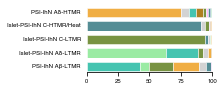

In [6]:
# ---- panel f: dendritic inputs
grouped_f = stacked_bars(dendritic, "figure4f_dendritic_inputs_bars.svg")


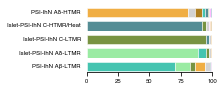

In [7]:
# ---- panel g: axoaxonic outputs
grouped_g = stacked_bars(axoaxonic, "figure4g_axoaxonic_outputs_bars.svg")


In [8]:
# Percentage table behind both panels.
for name, grouped in (("f  dendritic inputs", grouped_f),
                      ("g  axoaxonic outputs", grouped_g)):
    pct = grouped.div(grouped.sum(axis=1), axis=0).mul(100).round(1)
    pct.index = [POPULATION_LABELS[p] for p in pct.index]
    print(f"\n=== panel {name} (% of sensory synapses) ===")
    print(pct.reindex([POPULATION_LABELS[p] for p in POPULATION_ORDER]).to_string())



=== panel f  dendritic inputs (% of sensory synapses) ===
                           C-Cold  Aδ-HTMR  Peptidergic C-Nociceptors  C-HTMR/Heat (SST)  C-HTMR/Heat (MrgprA3,MrgprD,MrgprB4)  C-LTMR  Aδ-LTMR  Aβ-LTMR  Low-Confidence
PSI-IhN Aδ-HTMR               0.9     75.3                        5.1                2.1                                   1.4     2.5      0.6      5.8             6.4
Islet-PSI-IhN C-HTMR/Heat     0.0      0.8                        0.8                1.1                                  91.6     2.8      0.0      0.0             2.9
Islet-PSI-IhN C-LTMR          0.0      0.2                        0.1                0.2                                   2.3    94.7      0.5      0.3             1.8
Islet-PSI-IhN Aδ-LTMR         0.0      2.1                        0.3                0.1                                   0.5     4.4     63.6     24.8             4.2
PSI-IhN Aβ-LTMR               0.1     20.9                        0.2                0.3        